# Session 4.1 | Recurrent Neural Networks — Complete Hyperparameter Guide

**Author:** Dr. Milan Joshi | MathCanvasMJ  
**Session:** 4 — Recurrent Neural Networks  
**Framework:** TensorFlow / Keras

> *"The imagination of nature is far, far greater than the imagination of man."* — Richard Feynman

In this notebook, we build RNNs from scratch, understand every hyperparameter, and see how each one affects learning. By the end, you'll know exactly which knobs to turn and why.

## Table of Contents

1. [Why Recurrent Neural Networks?](#1.-Why-Recurrent-Neural-Networks?)
2. [The Vanishing Gradient Problem](#2.-The-Vanishing-Gradient-Problem)
3. [Synthetic Sine Wave Data](#3.-Synthetic-Sine-Wave-Data)
4. [Baseline RNN Model](#4.-Baseline-RNN-Model)
5. [Hyperparameter: Number of Units](#5.-Hyperparameter:-Number-of-Units)
6. [Stacked RNN — Adding Depth](#6.-Stacked-RNN-—-Adding-Depth)
7. [Activation Functions](#7.-Activation-Functions)
8. [Regularization: Dropout & Recurrent Dropout](#8.-Regularization:-Dropout-&-Recurrent-Dropout)
9. [Learning Rate & Optimizers](#9.-Learning-Rate-&-Optimizers)
10. [Batch Size & Window Size](#10.-Batch-Size-&-Window-Size)
11. [Weight Initialization & Regularization](#11.-Weight-Initialization-&-Regularization)

In [1]:
# ==== Imports and Reproducibility Setup ====
# We set seeds for NumPy, TensorFlow, and Python's random module
# to ensure reproducible results across runs.
# ==================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 100
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU available: []


## 1. Why Recurrent Neural Networks?

### The Limitation of Feedforward Networks

A feedforward network treats each input independently — it has **no memory**. But many real-world problems involve **sequences** where order matters:

- **Language**: "The cat sat on the ___" → predicting the next word requires context
- **Stock prices**: Today's price depends on yesterday's trend
- **Weather**: Tomorrow's temperature relates to today's pattern

> **Feynman Analogy**: Imagine reading a book by looking at random pages vs. reading page by page. The RNN reads page by page, carrying forward what it learned from previous pages.

### The RNN Solution: Memory Through Recurrence

An RNN processes sequences **one step at a time**, maintaining a **hidden state** $h_t$ that acts as memory.

### Mathematical Formulation

**Hidden State Update:**
$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$$

**Output:**
$$y_t = W_{hy} \cdot h_t + b_y$$

where:
- $x_t \in \mathbb{R}^{n_x}$ — input at time step $t$
- $h_t \in \mathbb{R}^{n_h}$ — hidden state at time $t$ (the "memory")
- $W_{xh} \in \mathbb{R}^{n_h \times n_x}$ — input-to-hidden weights
- $W_{hh} \in \mathbb{R}^{n_h \times n_h}$ — hidden-to-hidden weights (recurrent)
- $W_{hy} \in \mathbb{R}^{n_y \times n_h}$ — hidden-to-output weights
- $b_h, b_y$ — bias vectors

### Parameter Count Formula
$$\text{RNN params} = n_h \times (n_x + n_h + 1) + n_y \times (n_h + 1)$$

The key insight: **the same weights $W_{xh}$, $W_{hh}$ are shared across ALL time steps**. This is called **weight sharing** and is what makes RNNs efficient for variable-length sequences.

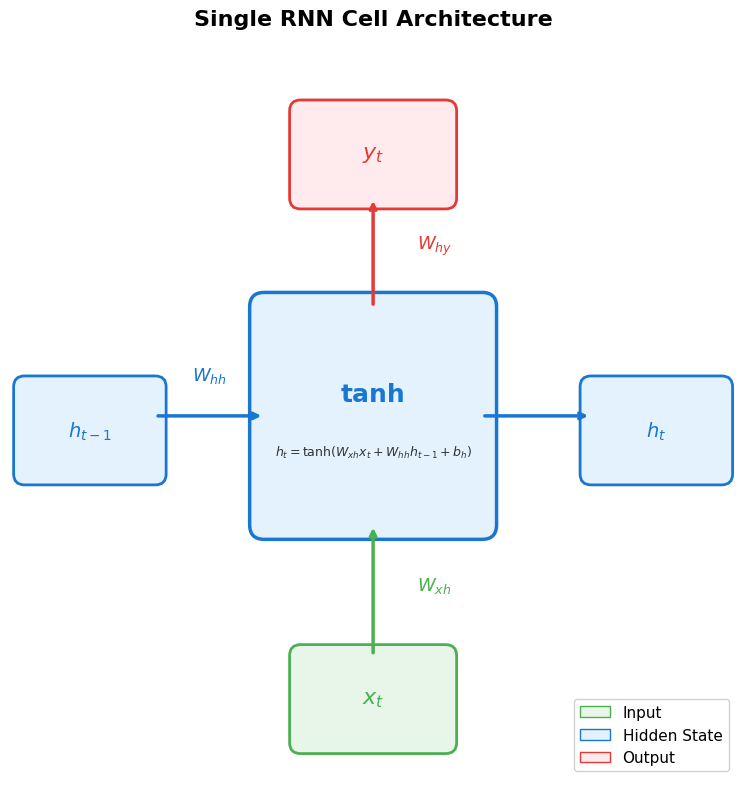

In [2]:
# ==== RNN Cell Architecture Diagram ====
# This diagram shows a SINGLE RNN cell with all its components:
# x_t (input), h_{t-1} (previous hidden state), h_t (new hidden state),
# y_t (output), and the weight matrices as labeled arrows.
# Colors: input=#4CAF50, hidden=#1976d2, output=#e53935
# ==================================================

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Single RNN Cell Architecture', fontsize=16, fontweight='bold', pad=20)

# Colors
c_input = '#4CAF50'
c_hidden = '#1976d2'
c_output = '#e53935'

# --- Draw the main RNN cell box ---
cell_box = mpatches.FancyBboxPatch((3.5, 3.5), 3, 3, boxstyle='round,pad=0.2',
                                     facecolor='#E3F2FD', edgecolor=c_hidden, linewidth=2.5)
ax.add_patch(cell_box)
ax.text(5, 5.3, 'tanh', fontsize=18, ha='center', va='center', fontweight='bold', color=c_hidden)
ax.text(5, 4.5, r'$h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$',
        fontsize=9, ha='center', va='center', color='#333')

# --- x_t input (bottom) ---
input_box = mpatches.FancyBboxPatch((4, 0.5), 2, 1.2, boxstyle='round,pad=0.15',
                                      facecolor='#E8F5E9', edgecolor=c_input, linewidth=2)
ax.add_patch(input_box)
ax.text(5, 1.1, r'$x_t$', fontsize=16, ha='center', va='center', fontweight='bold', color=c_input)

# Arrow from x_t to cell
ax.annotate('', xy=(5, 3.5), xytext=(5, 1.7),
            arrowprops=dict(arrowstyle='->', color=c_input, lw=2.5))
ax.text(5.6, 2.6, r'$W_{xh}$', fontsize=13, color=c_input, fontweight='bold')

# --- h_{t-1} input (left) ---
h_prev_box = mpatches.FancyBboxPatch((0.2, 4.2), 1.8, 1.2, boxstyle='round,pad=0.15',
                                       facecolor='#E3F2FD', edgecolor=c_hidden, linewidth=2)
ax.add_patch(h_prev_box)
ax.text(1.1, 4.8, r'$h_{t-1}$', fontsize=14, ha='center', va='center', fontweight='bold', color=c_hidden)

# Arrow from h_{t-1} to cell
ax.annotate('', xy=(3.5, 5), xytext=(2, 5),
            arrowprops=dict(arrowstyle='->', color=c_hidden, lw=2.5))
ax.text(2.5, 5.5, r'$W_{hh}$', fontsize=13, color=c_hidden, fontweight='bold')

# --- h_t output (right) ---
h_next_box = mpatches.FancyBboxPatch((8, 4.2), 1.8, 1.2, boxstyle='round,pad=0.15',
                                       facecolor='#E3F2FD', edgecolor=c_hidden, linewidth=2)
ax.add_patch(h_next_box)
ax.text(8.9, 4.8, r'$h_t$', fontsize=14, ha='center', va='center', fontweight='bold', color=c_hidden)

# Arrow from cell to h_t
ax.annotate('', xy=(8, 5), xytext=(6.5, 5),
            arrowprops=dict(arrowstyle='->', color=c_hidden, lw=2.5))

# --- y_t output (top) ---
output_box = mpatches.FancyBboxPatch((4, 8), 2, 1.2, boxstyle='round,pad=0.15',
                                       facecolor='#FFEBEE', edgecolor=c_output, linewidth=2)
ax.add_patch(output_box)
ax.text(5, 8.6, r'$y_t$', fontsize=16, ha='center', va='center', fontweight='bold', color=c_output)

# Arrow from cell to y_t
ax.annotate('', xy=(5, 8), xytext=(5, 6.5),
            arrowprops=dict(arrowstyle='->', color=c_output, lw=2.5))
ax.text(5.6, 7.3, r'$W_{hy}$', fontsize=13, color=c_output, fontweight='bold')

# --- Legend ---
legend_elements = [
    mpatches.Patch(facecolor='#E8F5E9', edgecolor=c_input, label='Input'),
    mpatches.Patch(facecolor='#E3F2FD', edgecolor=c_hidden, label='Hidden State'),
    mpatches.Patch(facecolor='#FFEBEE', edgecolor=c_output, label='Output'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

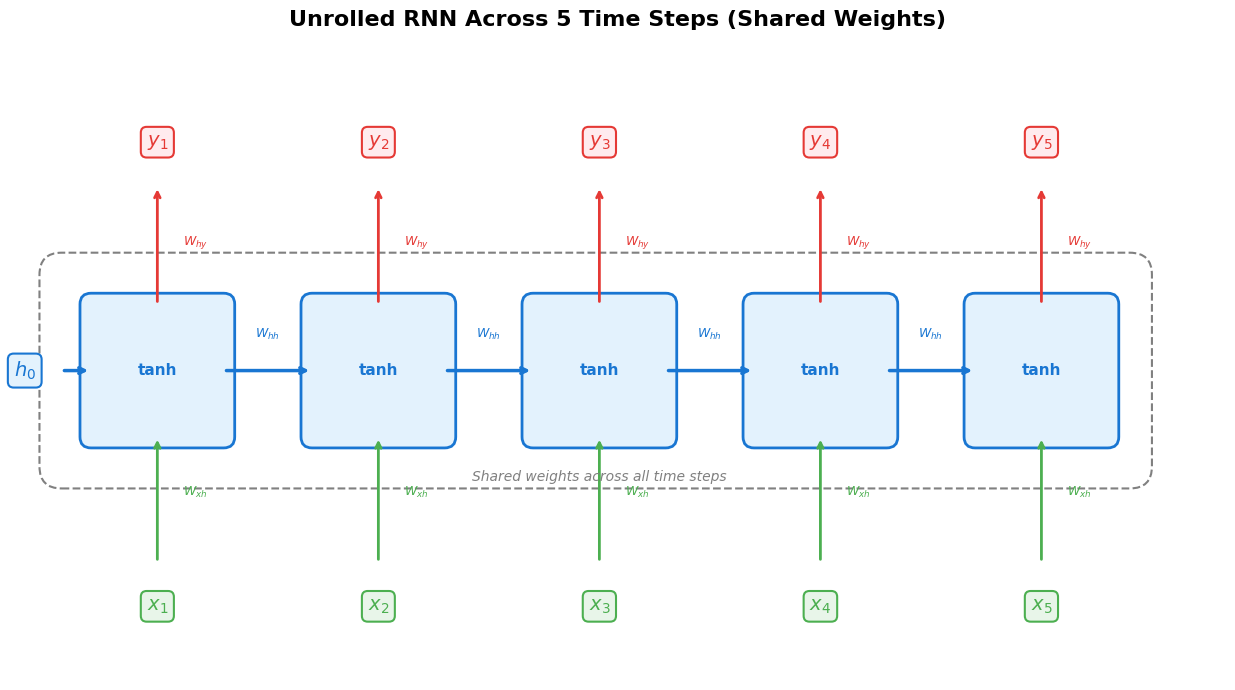

In [3]:
# ==== Unrolled RNN Diagram (5 Time Steps) ====
# This shows how the same RNN cell is applied repeatedly across
# 5 time steps. Dashed lines indicate that the SAME weight matrices
# (W_xh, W_hh) are shared at every step — this is "weight sharing".
# The recurrent connection h_{t-1} -> h_t is the key feature.
# ==================================================

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(-0.5, 16)
ax.set_ylim(-0.5, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Unrolled RNN Across 5 Time Steps (Shared Weights)', fontsize=16, fontweight='bold', pad=20)

c_input = '#4CAF50'
c_hidden = '#1976d2'
c_output = '#e53935'
n_steps = 5
spacing = 3.0

for i in range(n_steps):
    cx = 1.5 + i * spacing  # center x of this step

    # --- RNN Cell Box ---
    cell = mpatches.FancyBboxPatch((cx - 0.9, 2.8), 1.8, 1.8,
                                    boxstyle='round,pad=0.15',
                                    facecolor='#E3F2FD', edgecolor=c_hidden, linewidth=2)
    ax.add_patch(cell)
    ax.text(cx, 3.7, 'tanh', fontsize=11, ha='center', va='center',
            fontweight='bold', color=c_hidden)

    # --- x_t (bottom) ---
    ax.text(cx, 0.5, f'$x_{{{i+1}}}$', fontsize=14, ha='center', va='center',
            fontweight='bold', color=c_input,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor=c_input, linewidth=1.5))
    # Arrow x -> cell
    ax.annotate('', xy=(cx, 2.8), xytext=(cx, 1.1),
                arrowprops=dict(arrowstyle='->', color=c_input, lw=2))
    ax.text(cx + 0.35, 2.0, r'$W_{xh}$', fontsize=9, color=c_input, fontweight='bold')

    # --- y_t (top) ---
    ax.text(cx, 6.8, f'$y_{{{i+1}}}$', fontsize=14, ha='center', va='center',
            fontweight='bold', color=c_output,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor=c_output, linewidth=1.5))
    # Arrow cell -> y
    ax.annotate('', xy=(cx, 6.2), xytext=(cx, 4.6),
                arrowprops=dict(arrowstyle='->', color=c_output, lw=2))
    ax.text(cx + 0.35, 5.4, r'$W_{hy}$', fontsize=9, color=c_output, fontweight='bold')

    # --- Recurrent connection h_{t-1} -> h_t ---
    if i > 0:
        prev_cx = 1.5 + (i - 1) * spacing
        ax.annotate('', xy=(cx - 0.9, 3.7), xytext=(prev_cx + 0.9, 3.7),
                    arrowprops=dict(arrowstyle='->', color=c_hidden, lw=2.5))
        mid_x = (prev_cx + 0.9 + cx - 0.9) / 2
        ax.text(mid_x, 4.15, r'$W_{hh}$', fontsize=9, ha='center', color=c_hidden, fontweight='bold')

# --- h_0 on the far left ---
ax.text(-0.3, 3.7, r'$h_0$', fontsize=14, ha='center', va='center',
        fontweight='bold', color=c_hidden,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', edgecolor=c_hidden, linewidth=1.5))
ax.annotate('', xy=(1.5 - 0.9, 3.7), xytext=(0.2, 3.7),
            arrowprops=dict(arrowstyle='->', color=c_hidden, lw=2.5))

# --- Dashed box around all cells to show shared weights ---
shared_box = mpatches.FancyBboxPatch((0.2, 2.4), 14.5, 2.6,
                                       boxstyle='round,pad=0.3',
                                       facecolor='none', edgecolor='gray',
                                       linewidth=1.5, linestyle='dashed')
ax.add_patch(shared_box)
ax.text(7.5, 2.2, 'Shared weights across all time steps',
        fontsize=10, ha='center', color='gray', style='italic')

plt.tight_layout()
plt.show()

## 2. The Vanishing Gradient Problem

### Why RNNs Struggle with Long Sequences

During backpropagation through time (BPTT), gradients must flow back through every time step:

$$\frac{\partial L}{\partial W} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial W} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial h_t} \prod_{k=2}^{t} \frac{\partial h_k}{\partial h_{k-1}} \cdot \frac{\partial h_1}{\partial W}$$

The product $\prod_{k=2}^{t} \frac{\partial h_k}{\partial h_{k-1}}$ involves multiplying many terms. If each term is:
- **< 1**: Gradients **vanish** exponentially → network forgets distant past
- **> 1**: Gradients **explode** exponentially → training becomes unstable

For $\tanh$ activation: $|\tanh'(x)| \leq 1$, so gradients almost always vanish for long sequences.

> **Feynman Analogy**: It's like playing telephone with 50 people — by the time the message reaches the end, it's completely garbled. This is why vanilla RNNs struggle with sequences longer than ~20 steps.

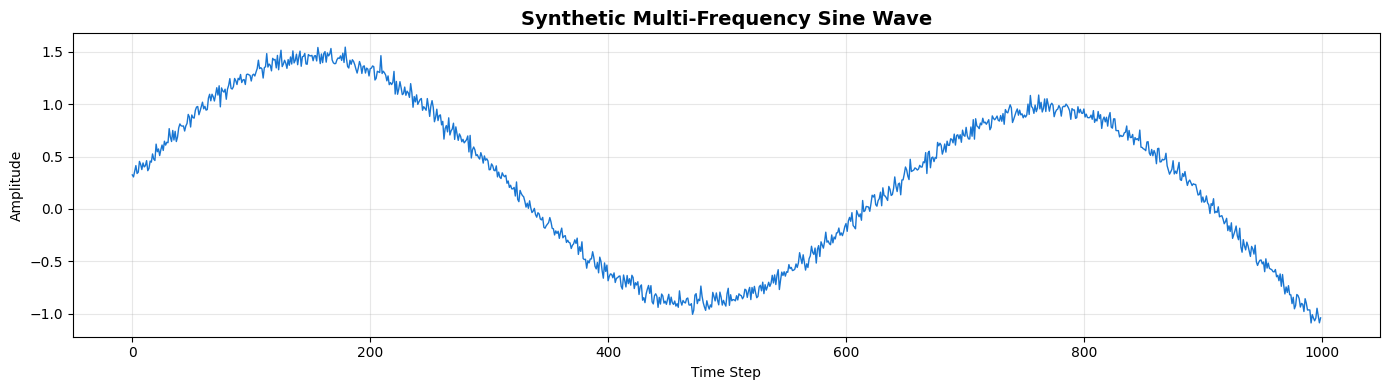

Data shape: (1000,), Range: [-1.09, 1.54]


In [4]:
# ==== Generate Multi-Frequency Sine Wave Data ====
# We create a synthetic signal with two frequencies.
# This is perfect for studying RNNs because:
#   1. We know the ground truth exactly
#   2. We can control complexity (more frequencies = harder)
#   3. No need for external data downloads
# ==================================================
def generate_sine_data(n_points=1000, noise_std=0.05):
    """Generate a multi-frequency sine wave with optional noise."""
    t = np.linspace(0, 100, n_points)
    signal = np.sin(0.1 * t) + 0.5 * np.sin(0.05 * t) + 0.3 * np.cos(0.08 * t)
    signal += np.random.normal(0, noise_std, n_points)
    return signal

data = generate_sine_data()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data, color='#1976d2', linewidth=1)
ax.set_title('Synthetic Multi-Frequency Sine Wave', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Data shape: {data.shape}, Range: [{data.min():.2f}, {data.max():.2f}]")

In [5]:
# ==== Data Preprocessing Pipeline ====
# 1. Normalize to [0, 1] with MinMaxScaler (neural nets work best here)
# 2. Create sliding window sequences: each input is `window_size` past values
# 3. Split 80/20 (time-based, NOT random — crucial for time series!)
# ==================================================
def create_sequences(data, window_size):
    """Create input/output pairs using a sliding window.
    
    For window_size=10: use values [t-10, ..., t-1] to predict value [t]
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Scale data to [0, 1]
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).flatten()

# Create sequences with window=20
WINDOW_SIZE = 20
X, y = create_sequences(data_scaled, WINDOW_SIZE)

# Time-based 80/20 split (NOT random!)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for RNN: [samples, timesteps, features]
X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
X_test = X_test.reshape(-1, WINDOW_SIZE, 1)

print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")
print(f"Window size:    {WINDOW_SIZE} time steps")
print(f"Input shape:    (samples, {WINDOW_SIZE} timesteps, 1 feature)")

Training set:   X=(784, 20, 1), y=(784,)
Test set:       X=(196, 20, 1), y=(196,)
Window size:    20 time steps
Input shape:    (samples, 20 timesteps, 1 feature)


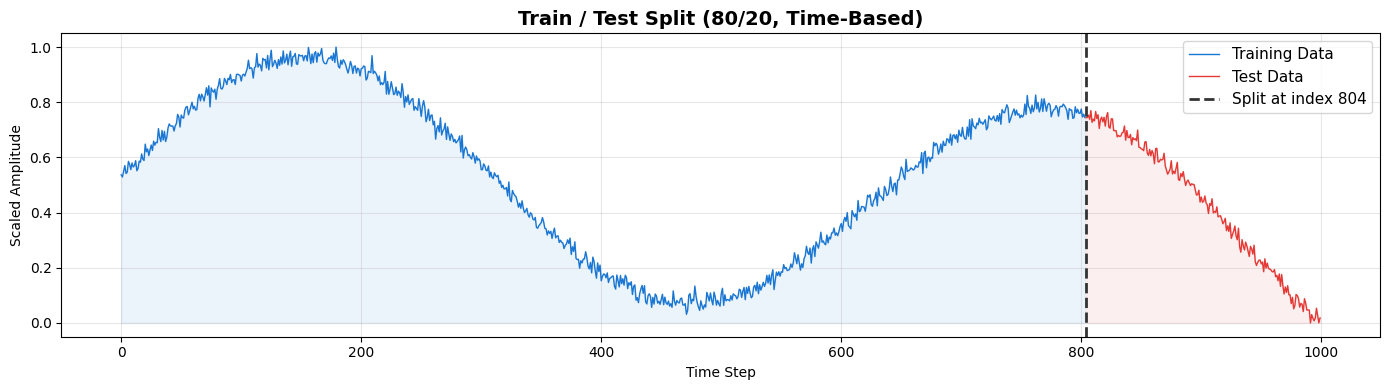

Training: indices 0–803  (804 points)
Test:     indices 804–999  (196 points)


In [6]:
# ==== Visualize Train/Test Split ====
# We plot the entire scaled dataset and color-code the
# training portion (blue) vs the test portion (orange)
# with a vertical dashed line at the split point.
# ==================================================

fig, ax = plt.subplots(figsize=(14, 4))
split_idx = split + WINDOW_SIZE  # adjust for window offset

ax.plot(range(split_idx), data_scaled[:split_idx], color='#1976d2', linewidth=1, label='Training Data')
ax.plot(range(split_idx, len(data_scaled)), data_scaled[split_idx:], color='#e53935', linewidth=1, label='Test Data')
ax.axvline(x=split_idx, color='#333', linestyle='--', linewidth=2, label=f'Split at index {split_idx}')

ax.fill_between(range(split_idx), data_scaled[:split_idx], alpha=0.08, color='#1976d2')
ax.fill_between(range(split_idx, len(data_scaled)), data_scaled[split_idx:], alpha=0.08, color='#e53935')

ax.set_title('Train / Test Split (80/20, Time-Based)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Scaled Amplitude')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training: indices 0–{split_idx-1}  ({split_idx} points)")
print(f"Test:     indices {split_idx}–{len(data_scaled)-1}  ({len(data_scaled)-split_idx} points)")

## 4. Baseline RNN Model

We start with the simplest possible RNN:
- **1 SimpleRNN layer** with 32 units
- **1 Dense output layer** (single value prediction)
- **Adam optimizer** with default learning rate
- **MSE loss** (standard for regression)

This gives us a performance reference point. Every experiment below will be compared against this baseline.

> **Feynman Principle**: Always start with the simplest model that could possibly work. Add complexity only when you understand why it's needed.

In [16]:
# importing LSTM and Bidirectional layers for the baseline model
from tensorflow.keras.layers import LSTM, Bidirectional

In [ ]:
# ==== Baseline RNN: SimpleRNN(32) + Dense(1) ====
# This is our performance reference. We use Adam optimizer
# with MSE loss. 100 epochs with 10% validation split from
# the training data for monitoring convergence.
# ==================================================

tf.random.set_seed(42)
np.random.seed(42)

baseline_model = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

"""
actgivation function: relu/tanh
weights: He/Glorot      recurrent: orthogonal
regularization: l1/l2/l1-l2
cropout/recurrent dropout: 0.1to0.2
stacking

"""

baseline_model = Sequential([
    Bidirectional(LSTM(32, activation='tanh', input_shape=(WINDOW_SIZE, 1), return_sequences=True, kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal')),
    Bidirectional(LSTM(32, activation='tanh')),
    Dense(1)
])


baseline_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
baseline_model.summary()

print("\n" + "="*60)
print("Training baseline model...")
print("="*60)

baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print(f"Final training loss:   {baseline_history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {baseline_history.history['val_loss'][-1]:.6f}")





Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_12                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training baseline model...
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.0649 - val_loss: 0.0149
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0049 - val_loss: 0.0012
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0017 - val_loss: 4.7179e-04
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0015 - val_loss: 4.4632e-04
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0014 - val_loss: 4.4247e-04
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0014 - val_loss: 4.3964e-04
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0014 - val_loss: 4.3739e-04
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0014 - val_loss: 4.3491e-04
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0014 - val_loss: 4.3247e-04
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013 - val_loss: 4.3006e-04
Final training loss:   0.001333
Final validation loss: 0.000430


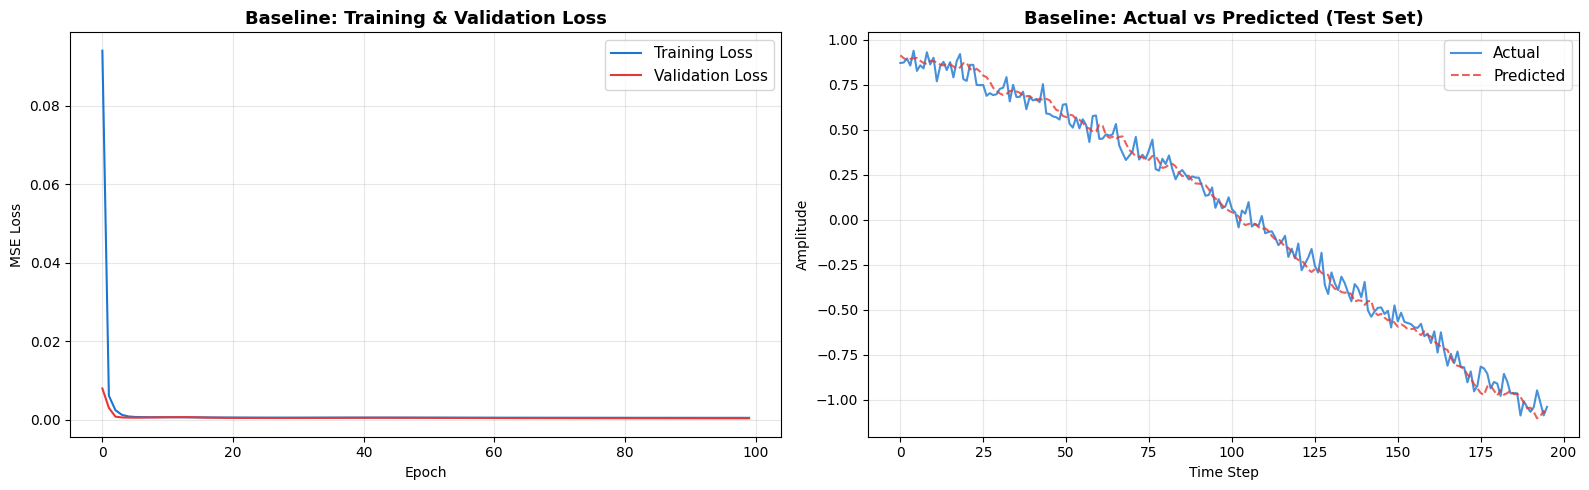


Baseline Model Metrics
RMSE:  0.0566
MAE:   0.0456
R²:    0.9915


In [8]:
# ==== Baseline Model Evaluation ====
# 1. Plot training vs validation loss curves to check convergence
# 2. Generate predictions on the test set
# 3. Inverse-transform predictions to original scale
# 4. Compute RMSE, MAE, and R² metrics
# ==================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Loss Curves ---
axes[0].plot(baseline_history.history['loss'], label='Training Loss', color='#1976d2', linewidth=1.5)
axes[0].plot(baseline_history.history['val_loss'], label='Validation Loss', color='#e53935', linewidth=1.5)
axes[0].set_title('Baseline: Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Predictions ---
y_pred_scaled = baseline_model.predict(X_test, verbose=0).flatten()

# Inverse transform to original scale
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_orig = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

axes[1].plot(y_test_orig, label='Actual', color='#1976d2', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_orig, label='Predicted', color='#e53935', linewidth=1.5, linestyle='--', alpha=0.8)
axes[1].set_title('Baseline: Actual vs Predicted (Test Set)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Amplitude')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Metrics ---
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"\n{'='*40}")
print(f"Baseline Model Metrics")
print(f"{'='*40}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE:   {mae:.4f}")
print(f"R\u00b2:    {r2:.4f}")

## 5. Hyperparameter: Number of Units

The number of units in an RNN layer controls **how much information the hidden state can remember**.

$$h_t \in \mathbb{R}^{n_h}$$

- **Few units** (e.g., 8): The hidden state is a small vector → limited memory capacity → may underfit
- **Many units** (e.g., 128): Large hidden state → more capacity → can memorize training data → may overfit

### Effect on Parameter Count

For a SimpleRNN with $n_x = 1$ input feature and $n_h$ units:
$$\text{RNN layer params} = n_h \times (n_x + n_h + 1) = n_h \times (1 + n_h + 1) = n_h^2 + 2n_h$$

This grows **quadratically** with units — doubling units roughly quadruples parameters!

> **Feynman Insight**: Think of units as the number of "slots" in the RNN's notepad. More slots let it track more things simultaneously, but also give it more room to write down irrelevant details.

Training with units=8... RMSE=0.0588, Params=89, Time=21.6s
Training with units=16... WARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002606B61AF20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
RMSE=0.0632, Params=305, Time=18.7s
Training with units=32... WARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_

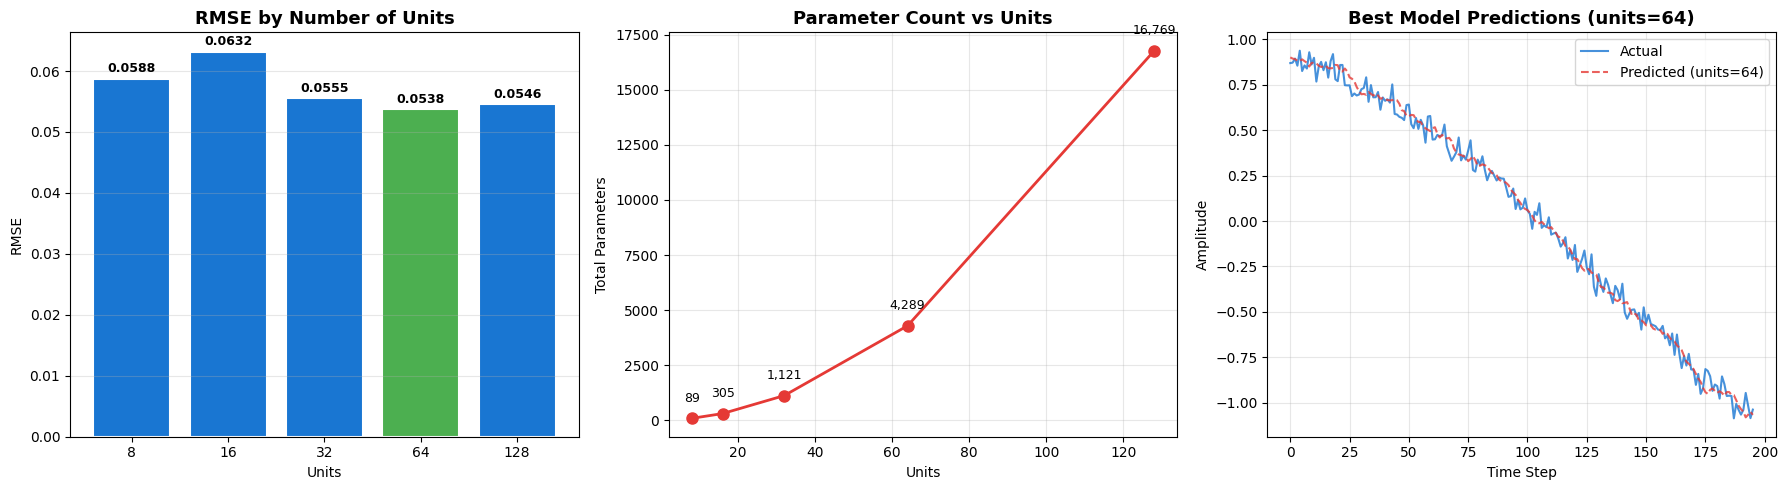

In [9]:
# ==== Units Sweep: 8, 16, 32, 64, 128 ====
# We define reusable functions for building and evaluating RNN models,
# then sweep across different unit counts. For each, we record:
# - RMSE on the test set
# - Total parameter count
# - Training time
# Finally, we create a multi-panel figure showing all results.
# ==================================================

def build_simple_rnn(units, window_size=20, lr=0.001):
    """Build a simple RNN model with given number of units."""
    model = Sequential([
        SimpleRNN(units, activation='tanh', input_shape=(window_size, 1)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

def train_and_evaluate(model, X_tr, y_tr, X_te, y_te, epochs=100, batch_size=32, verbose=0):
    """Train a model and return history, predictions, metrics, and timing."""
    start_time = time.time()
    history = model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch_size,
                        validation_split=0.1, verbose=verbose)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_te, verbose=0).flatten()
    
    # Inverse transform
    y_te_orig = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()
    y_pr_orig = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_te_orig, y_pr_orig))
    mae = mean_absolute_error(y_te_orig, y_pr_orig)
    r2 = r2_score(y_te_orig, y_pr_orig)
    
    return {
        'history': history,
        'y_pred': y_pr_orig,
        'y_true': y_te_orig,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'train_time': train_time,
        'params': model.count_params()
    }

# --- Sweep ---
units_list = [8, 16, 32, 64, 128]
units_results = {}

for u in units_list:
    print(f"Training with units={u}...", end=' ')
    tf.random.set_seed(42)
    np.random.seed(42)
    model = build_simple_rnn(u)
    result = train_and_evaluate(model, X_train, y_train, X_test, y_test)
    units_results[u] = result
    print(f"RMSE={result['rmse']:.4f}, Params={result['params']}, Time={result['train_time']:.1f}s")

# --- Multi-Panel Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: RMSE Bar Chart
rmse_vals = [units_results[u]['rmse'] for u in units_list]
colors = ['#4CAF50' if v == min(rmse_vals) else '#1976d2' for v in rmse_vals]
axes[0].bar([str(u) for u in units_list], rmse_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('RMSE by Number of Units', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Units')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# Panel 2: Parameter Count
param_vals = [units_results[u]['params'] for u in units_list]
axes[1].plot(units_list, param_vals, 'o-', color='#e53935', linewidth=2, markersize=8)
axes[1].set_title('Parameter Count vs Units', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Units')
axes[1].set_ylabel('Total Parameters')
axes[1].grid(True, alpha=0.3)
for u, p in zip(units_list, param_vals):
    axes[1].annotate(f'{p:,}', (u, p), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9)

# Panel 3: Best Model Predictions
best_u = units_list[np.argmin(rmse_vals)]
axes[2].plot(units_results[best_u]['y_true'], label='Actual', color='#1976d2', linewidth=1.5, alpha=0.8)
axes[2].plot(units_results[best_u]['y_pred'], label=f'Predicted (units={best_u})',
             color='#e53935', linewidth=1.5, linestyle='--', alpha=0.8)
axes[2].set_title(f'Best Model Predictions (units={best_u})', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Amplitude')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Stacked RNN — Adding Depth

Stacking RNN layers creates a **deep RNN** that can learn hierarchical temporal features:
- **Layer 1**: Captures low-level patterns (short-term fluctuations)
- **Layer 2**: Captures mid-level patterns (trends)
- **Layer 3**: Captures high-level patterns (seasonal cycles)

**Critical:** All layers except the last must set `return_sequences=True` to pass the full sequence (not just the final hidden state) to the next RNN layer.

### Data Flow in a Stacked RNN

```
Input (samples, 20, 1)
   ↓
SimpleRNN Layer 1 (return_sequences=True)  → Output: (samples, 20, 32)
   ↓
SimpleRNN Layer 2 (return_sequences=True)  → Output: (samples, 20, 32)
   ↓
SimpleRNN Layer 3 (return_sequences=False) → Output: (samples, 32)
   ↓
Dense Layer                                → Output: (samples, 1)
```

Training 1-layer RNN... RMSE=0.0577, Params=1121
Training 2-layer RNN... RMSE=0.0814, Params=3201
Training 3-layer RNN... RMSE=0.0553, Params=5281


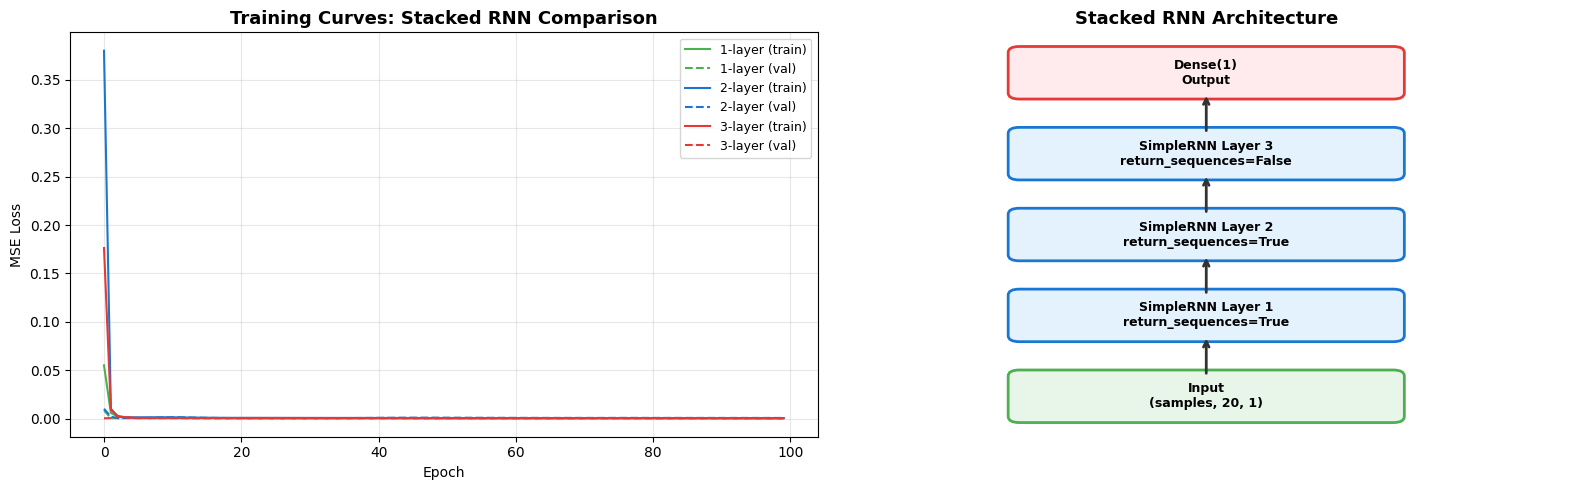


Results Summary:
  1-layer: RMSE=0.0577, R²=0.9911, Params=1,121
  2-layer: RMSE=0.0814, R²=0.9824, Params=3,201
  3-layer: RMSE=0.0553, R²=0.9919, Params=5,281


In [10]:
# ==== Stacked RNN: 1-Layer vs 2-Layer vs 3-Layer ====
# We compare depth by stacking RNN layers.
# return_sequences=True is critical for all layers except the last.
# We also draw a stacked RNN diagram showing how data flows
# through multiple layers at each time step.
# ==================================================

def build_stacked_rnn(num_layers, units=32, window_size=20, lr=0.001):
    """Build a stacked RNN model with given depth."""
    model = Sequential()
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        if i == 0:
            model.add(SimpleRNN(units, activation='tanh', return_sequences=return_seq,
                                input_shape=(window_size, 1)))
        else:
            model.add(SimpleRNN(units, activation='tanh', return_sequences=return_seq))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

layer_configs = [1, 2, 3]
layer_results = {}

for nl in layer_configs:
    print(f"Training {nl}-layer RNN...", end=' ')
    tf.random.set_seed(42)
    np.random.seed(42)
    model = build_stacked_rnn(nl)
    result = train_and_evaluate(model, X_train, y_train, X_test, y_test)
    layer_results[nl] = result
    print(f"RMSE={result['rmse']:.4f}, Params={result['params']}")

# --- Plot: Overlaid Training Curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_layers = {1: '#4CAF50', 2: '#1976d2', 3: '#e53935'}
for nl in layer_configs:
    axes[0].plot(layer_results[nl]['history'].history['loss'],
                 label=f'{nl}-layer (train)', color=colors_layers[nl], linewidth=1.5)
    axes[0].plot(layer_results[nl]['history'].history['val_loss'],
                 label=f'{nl}-layer (val)', color=colors_layers[nl], linewidth=1.5, linestyle='--')
axes[0].set_title('Training Curves: Stacked RNN Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Stacked RNN Diagram ---
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Stacked RNN Architecture', fontsize=13, fontweight='bold')

layer_labels = ['Input\n(samples, 20, 1)', 'SimpleRNN Layer 1\nreturn_sequences=True',
                'SimpleRNN Layer 2\nreturn_sequences=True',
                'SimpleRNN Layer 3\nreturn_sequences=False', 'Dense(1)\nOutput']
layer_colors = ['#E8F5E9', '#E3F2FD', '#E3F2FD', '#E3F2FD', '#FFEBEE']
edge_colors = ['#4CAF50', '#1976d2', '#1976d2', '#1976d2', '#e53935']
y_positions = [1, 3, 5, 7, 9]

for i, (lbl, yp, fc, ec) in enumerate(zip(layer_labels, y_positions, layer_colors, edge_colors)):
    box = mpatches.FancyBboxPatch((2.5, yp - 0.5), 5, 1.0,
                                    boxstyle='round,pad=0.15',
                                    facecolor=fc, edgecolor=ec, linewidth=2)
    ax.add_patch(box)
    ax.text(5, yp, lbl, fontsize=9, ha='center', va='center', fontweight='bold')
    if i > 0:
        ax.annotate('', xy=(5, yp - 0.5), xytext=(5, y_positions[i-1] + 0.5),
                    arrowprops=dict(arrowstyle='->', color='#333', lw=2))

plt.tight_layout()
plt.show()

print("\nResults Summary:")
for nl in layer_configs:
    r = layer_results[nl]
    print(f"  {nl}-layer: RMSE={r['rmse']:.4f}, R\u00b2={r['r2']:.4f}, Params={r['params']:,}")

## 7. Activation Functions

The activation function in an RNN determines how the hidden state is transformed at each time step. The choice profoundly affects gradient flow.

### tanh (Hyperbolic Tangent)
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
- Output range: $(-1, 1)$
- Zero-centered (unlike sigmoid)
- Derivative: $\tanh'(x) = 1 - \tanh^2(x)$, max at $x=0$ is 1
- **Default for RNNs** because it helps with gradient flow

### ReLU (Rectified Linear Unit)
$$\text{ReLU}(x) = \max(0, x)$$
- Output range: $[0, \infty)$
- Derivative: 0 or 1 (no vanishing gradient for positive inputs!)
- Risk: **Exploding activations** in RNNs (hidden state grows unboundedly)

### Sigmoid
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
- Output range: $(0, 1)$
- Derivative: $\sigma'(x) = \sigma(x)(1-\sigma(x))$, max is 0.25
- **Worst for vanishing gradients** (max derivative is only 0.25!)

> **Feynman Insight**: tanh is the Goldilocks activation for RNNs — it's bounded (prevents explosion) and zero-centered (helps gradient flow). ReLU is great for feedforward nets but dangerous in recurrent settings.

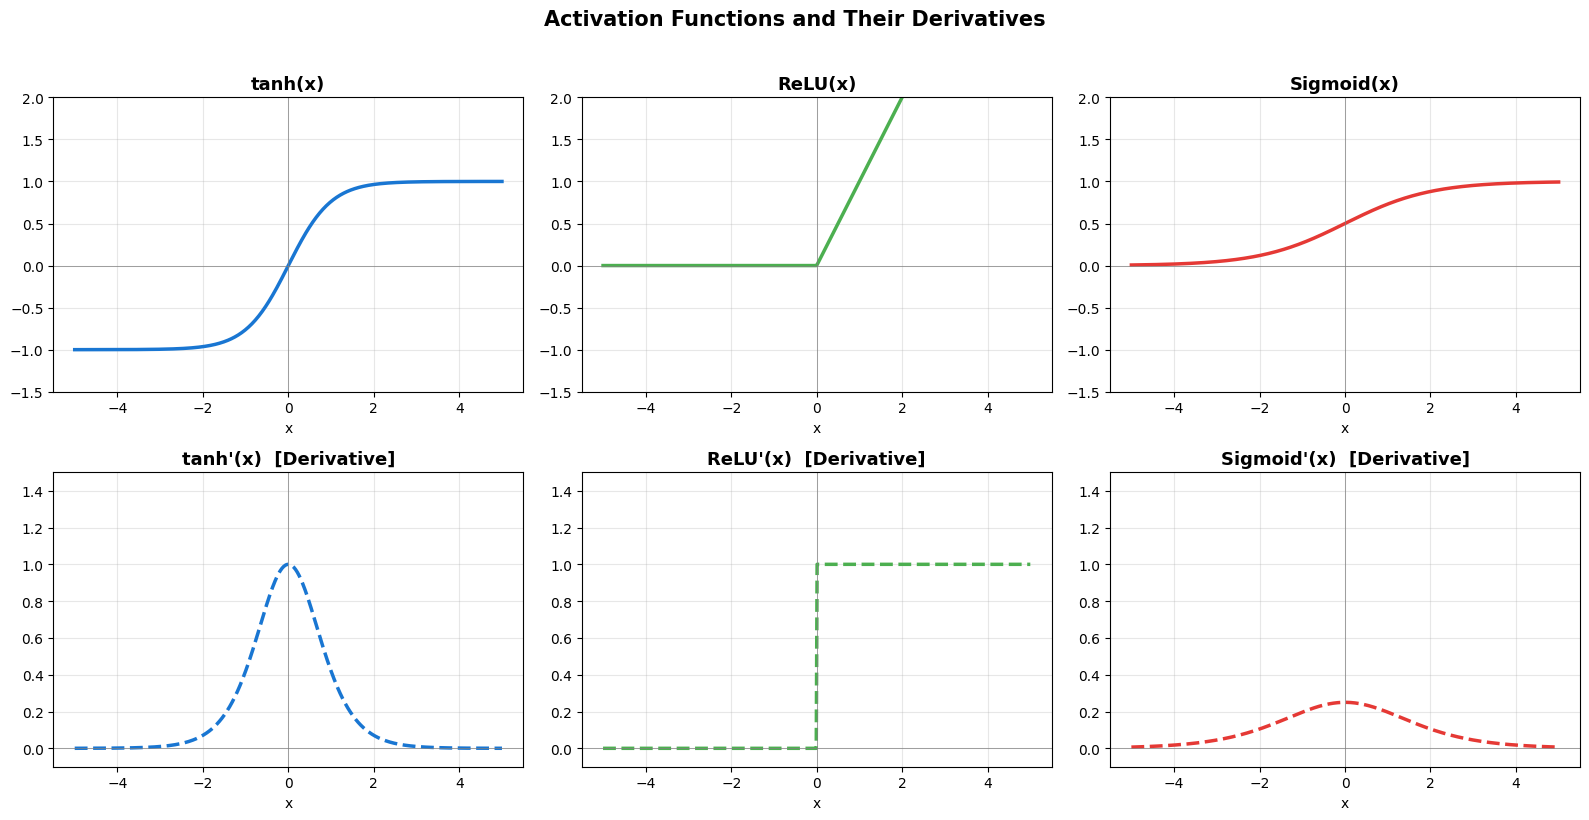

Training with activation='tanh'... RMSE=0.0567
Training with activation='relu'... RMSE=0.0593
Training with activation='sigmoid'... RMSE=0.0588


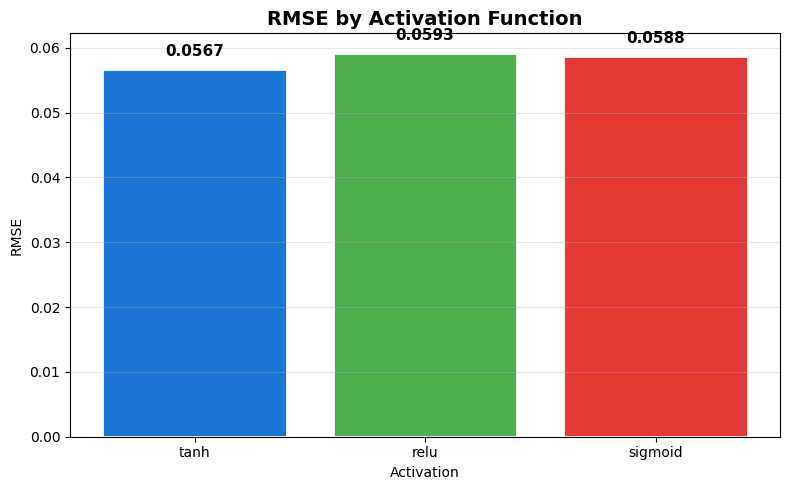

In [11]:
# ==== Activation Functions: Visualization & Comparison ====
# Part 1: Plot each activation function and its derivative.
# Part 2: Train RNN models with tanh, relu, sigmoid activations.
# Part 3: Compare RMSE across activations with a bar chart.
# ==================================================

# --- Part 1: Plot Activations and Derivatives ---
x_vals = np.linspace(-5, 5, 500)

# Functions
tanh_y = np.tanh(x_vals)
relu_y = np.maximum(0, x_vals)
sigmoid_y = 1 / (1 + np.exp(-x_vals))

# Derivatives
tanh_dy = 1 - np.tanh(x_vals)**2
relu_dy = (x_vals > 0).astype(float)
sigmoid_dy = sigmoid_y * (1 - sigmoid_y)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

activations = [
    ('tanh', tanh_y, tanh_dy, '#1976d2'),
    ('ReLU', relu_y, relu_dy, '#4CAF50'),
    ('Sigmoid', sigmoid_y, sigmoid_dy, '#e53935')
]

for col, (name, y, dy, color) in enumerate(activations):
    # Function
    axes[0, col].plot(x_vals, y, color=color, linewidth=2.5)
    axes[0, col].axhline(y=0, color='gray', linewidth=0.5)
    axes[0, col].axvline(x=0, color='gray', linewidth=0.5)
    axes[0, col].set_title(f'{name}(x)', fontsize=13, fontweight='bold')
    axes[0, col].set_xlabel('x')
    axes[0, col].grid(True, alpha=0.3)
    axes[0, col].set_ylim(-1.5, 2.0)
    
    # Derivative
    axes[1, col].plot(x_vals, dy, color=color, linewidth=2.5, linestyle='--')
    axes[1, col].axhline(y=0, color='gray', linewidth=0.5)
    axes[1, col].axvline(x=0, color='gray', linewidth=0.5)
    axes[1, col].set_title(f"{name}'(x)  [Derivative]", fontsize=13, fontweight='bold')
    axes[1, col].set_xlabel('x')
    axes[1, col].grid(True, alpha=0.3)
    axes[1, col].set_ylim(-0.1, 1.5)

plt.suptitle('Activation Functions and Their Derivatives', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Part 2: Train RNNs with different activations ---
act_names = ['tanh', 'relu', 'sigmoid']
act_results = {}

for act in act_names:
    print(f"Training with activation='{act}'...", end=' ')
    tf.random.set_seed(42)
    np.random.seed(42)
    model = Sequential([
        SimpleRNN(32, activation=act, input_shape=(WINDOW_SIZE, 1)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    result = train_and_evaluate(model, X_train, y_train, X_test, y_test)
    act_results[act] = result
    print(f"RMSE={result['rmse']:.4f}")

# --- Part 3: RMSE Bar Chart ---
fig, ax = plt.subplots(figsize=(8, 5))
act_rmse = [act_results[a]['rmse'] for a in act_names]
act_colors = ['#1976d2', '#4CAF50', '#e53935']
bars = ax.bar(act_names, act_rmse, color=act_colors, edgecolor='white', linewidth=2)
ax.set_title('RMSE by Activation Function', fontsize=14, fontweight='bold')
ax.set_xlabel('Activation')
ax.set_ylabel('RMSE')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, act_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Regularization: Dropout & Recurrent Dropout

**Dropout**: Randomly zeros out a fraction of the connections between layers at each training step. Prevents co-adaptation of neurons.

**Recurrent Dropout**: Randomly zeros out connections within the recurrent connections ($W_{hh}$). Prevents the hidden state from memorizing specific patterns.

$$\tilde{h}_t = \text{mask} \odot h_{t-1}$$

where $\text{mask}$ is a binary vector with entries sampled from $\text{Bernoulli}(1 - p_{\text{dropout}})$.

### Key Differences

| Type | What it drops | Effect |
|---|---|---|
| `dropout` | Input-to-hidden connections | Regularizes the input processing |
| `recurrent_dropout` | Hidden-to-hidden connections | Regularizes the memory/recurrence |

> **Feynman Analogy**: Dropout is like randomly covering some words on a page while studying — it forces you to understand the overall meaning, not just memorize specific words. Recurrent dropout does the same for your memory of previous pages.

Training dropout=0.0, recurrent_dropout=0.0... 

KeyboardInterrupt: 

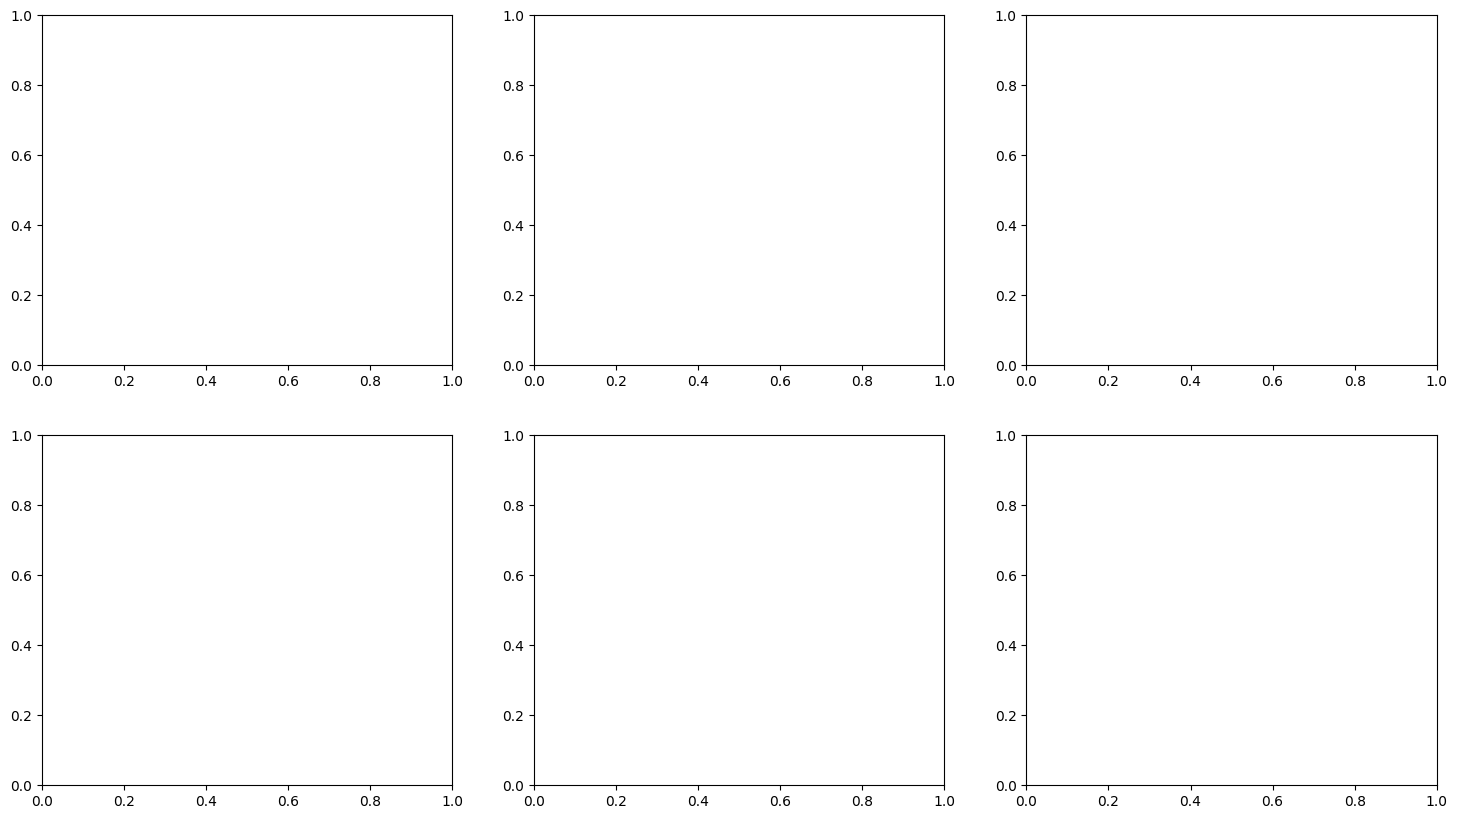

In [12]:
# ==== Dropout & Recurrent Dropout Sweep ====
# We test dropout rates [0.0, 0.1, 0.2, 0.3, 0.5] combined with
# recurrent_dropout rates [0.0, 0.1, 0.2]. For visualization,
# we create a 2x3 subplot grid showing train vs val loss for
# selected configurations to demonstrate overfitting reduction.
# ==================================================

dropout_vals = [0.0, 0.1, 0.2, 0.3, 0.5]
rec_dropout_vals = [0.0, 0.1, 0.2]

# Select 6 representative configurations for the 2x3 grid
configs = [
    (0.0, 0.0),   # No regularization
    (0.1, 0.0),   # Light dropout only
    (0.2, 0.0),   # Moderate dropout only
    (0.0, 0.2),   # Recurrent dropout only
    (0.2, 0.1),   # Combined light
    (0.3, 0.2),   # Combined heavy
]

dropout_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, (d, rd) in enumerate(configs):
    print(f"Training dropout={d}, recurrent_dropout={rd}...", end=' ')
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = Sequential([
        SimpleRNN(32, activation='tanh', dropout=d, recurrent_dropout=rd,
                  input_shape=(WINDOW_SIZE, 1)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    result = train_and_evaluate(model, X_train, y_train, X_test, y_test)
    dropout_results[(d, rd)] = result
    print(f"RMSE={result['rmse']:.4f}")
    
    # Plot train vs val loss
    ax = axes_flat[idx]
    ax.plot(result['history'].history['loss'], label='Train', color='#1976d2', linewidth=1.5)
    ax.plot(result['history'].history['val_loss'], label='Val', color='#e53935', linewidth=1.5)
    ax.set_title(f'dropout={d}, rec_dropout={rd}\nRMSE={result["rmse"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Dropout & Recurrent Dropout on Overfitting',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nAll Configurations Tested:")
for (d, rd), r in dropout_results.items():
    gap = r['history'].history['val_loss'][-1] - r['history'].history['loss'][-1]
    print(f"  dropout={d:.1f}, rec_dropout={rd:.1f}: RMSE={r['rmse']:.4f}, "
          f"Train-Val Gap={gap:.6f}")

## 9. Learning Rate & Optimizers

The **learning rate** $\alpha$ controls how large a step we take during gradient descent. It is arguably the **most important hyperparameter** in deep learning.

### Adam Optimizer (Adaptive Moment Estimation)

Adam combines momentum and adaptive learning rates:

**First moment (mean of gradients):**
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$

**Second moment (mean of squared gradients):**
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

**Bias-corrected estimates:**
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Parameter update:**
$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Default values: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-7}$

### Optimizer Comparison

| Optimizer | Adaptive LR | Momentum | Best For |
|---|---|---|---|
| SGD + Momentum | No | Yes | Final fine-tuning, well-understood problems |
| RMSprop | Yes | No | RNNs (Hinton designed it for this!) |
| Adam | Yes | Yes | General default, works well almost everywhere |

In [ ]:
# ==== Learning Rate & Optimizer Comparison ====
# We test 5 optimizer/learning-rate combinations:
# 1. Adam(lr=0.001)  - default
# 2. Adam(lr=0.01)   - aggressive
# 3. Adam(lr=0.0001) - conservative
# 4. SGD(lr=0.01, momentum=0.9)
# 5. RMSprop(lr=0.001)
# We create a 2x3 panel of training curves.
# ==================================================

optimizer_configs = [
    ('Adam (lr=0.001)',  Adam(learning_rate=0.001)),
    ('Adam (lr=0.01)',   Adam(learning_rate=0.01)),
    ('Adam (lr=0.0001)', Adam(learning_rate=0.0001)),
    ('SGD (lr=0.01, m=0.9)', SGD(learning_rate=0.01, momentum=0.9)),
    ('RMSprop (lr=0.001)', RMSprop(learning_rate=0.001)),
]

opt_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

colors_opt = ['#1976d2', '#e53935', '#4CAF50', '#FF9800', '#9C27B0']

for idx, (name, opt) in enumerate(optimizer_configs):
    print(f"Training with {name}...", end=' ')
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = Sequential([
        SimpleRNN(32, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
        Dense(1)
    ])
    model.compile(optimizer=opt, loss='mse')
    result = train_and_evaluate(model, X_train, y_train, X_test, y_test)
    opt_results[name] = result
    print(f"RMSE={result['rmse']:.4f}")
    
    ax = axes_flat[idx]
    ax.plot(result['history'].history['loss'], label='Train', color=colors_opt[idx], linewidth=1.5)
    ax.plot(result['history'].history['val_loss'], label='Val',
            color=colors_opt[idx], linewidth=1.5, linestyle='--')
    ax.set_title(f'{name}\nRMSE={result["rmse"]:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Turn off the unused 6th subplot
axes_flat[5].axis('off')
axes_flat[5].text(0.5, 0.5, 'Optimizer\nComparison\nComplete',
                  ha='center', va='center', fontsize=14, color='gray',
                  transform=axes_flat[5].transAxes)

plt.suptitle('Learning Rate & Optimizer Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ==== Callbacks: ReduceLROnPlateau + EarlyStopping ====
# These callbacks automate learning rate scheduling and prevent
# unnecessary training. ReduceLROnPlateau reduces the learning
# rate when validation loss stalls. EarlyStopping halts training
# when no improvement is seen for `patience` epochs.
# ==================================================

tf.random.set_seed(42)
np.random.seed(42)

model_cb = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])
model_cb.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Define callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Watch validation loss
    factor=0.5,           # Halve the learning rate
    patience=10,          # Wait 10 epochs before reducing
    min_lr=1e-6,          # Don't go below this
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',       # Watch validation loss
    patience=20,              # Stop after 20 epochs without improvement
    restore_best_weights=True # Revert to the best model
)

print("Training with ReduceLROnPlateau + EarlyStopping...")
print("Starting LR=0.01, will reduce by 0.5x on plateau\n")

history_cb = model_cb.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[reduce_lr, early_stop],
    verbose=0
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cb.history['loss'], label='Train Loss', color='#1976d2', linewidth=1.5)
axes[0].plot(history_cb.history['val_loss'], label='Val Loss', color='#e53935', linewidth=1.5)
axes[0].axvline(x=len(history_cb.history['loss'])-1, color='gray', linestyle='--',
               label=f'EarlyStopping (epoch {len(history_cb.history["loss"])})')
axes[0].set_title('Loss with Callbacks', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Learning rate schedule (if tracked)
if 'lr' in history_cb.history:
    axes[1].plot(history_cb.history['lr'], color='#4CAF50', linewidth=2)
    axes[1].set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)
else:
    # Predictions plot if lr not tracked
    y_pred_cb = model_cb.predict(X_test, verbose=0).flatten()
    y_test_cb = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_cb_orig = scaler.inverse_transform(y_pred_cb.reshape(-1, 1)).flatten()
    axes[1].plot(y_test_cb, label='Actual', color='#1976d2', linewidth=1.5)
    axes[1].plot(y_pred_cb_orig, label='Predicted', color='#e53935', linewidth=1.5, linestyle='--')
    axes[1].set_title('Predictions with Callbacks', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Time Step')
    axes[1].set_ylabel('Amplitude')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate
y_pred_cb = model_cb.predict(X_test, verbose=0).flatten()
y_pred_cb_orig = scaler.inverse_transform(y_pred_cb.reshape(-1, 1)).flatten()
y_test_orig_cb = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
rmse_cb = np.sqrt(mean_squared_error(y_test_orig_cb, y_pred_cb_orig))
print(f"\nCallback Model RMSE: {rmse_cb:.4f}")
print(f"Stopped at epoch: {len(history_cb.history['loss'])}")
print(f"Final learning rate: {history_cb.history.get('lr', ['N/A'])[-1]}")

## 10. Batch Size & Window Size

### Batch Size

The batch size determines how many samples the model sees before updating weights:

- **Small batch** (8-16): Noisier gradients, better generalization, slower training
- **Large batch** (64-128): Smoother gradients, faster training, may converge to sharp minima

### Window Size (Sequence Length)

The window size determines how far back in time the model looks:

- **Short window** (5): Can only capture short-term patterns
- **Long window** (50): Can capture longer patterns, but:
  - More prone to vanishing gradients
  - More computational cost
  - May include irrelevant history

The **optimal window** should match the **characteristic timescale** of the patterns in your data.

> **Feynman Insight**: Choosing the window size is like choosing how far back in your notes to study for an exam. Too little and you miss key concepts; too much and you waste time on irrelevant material.

In [ ]:
# ==== Batch Size x Window Size Grid Search ====
# We test batch_size=[8,16,32,64] x window_size=[5,10,20,50]
# and create a heatmap of RMSE values. We use 50 epochs
# to keep training time manageable while still seeing
# meaningful differences between configurations.
# ==================================================

batch_sizes = [8, 16, 32, 64]
window_sizes = [5, 10, 20, 50]
rmse_grid = np.zeros((len(batch_sizes), len(window_sizes)))

print("Running Batch Size x Window Size grid search (50 epochs each)...")
print(f"Total configurations: {len(batch_sizes) * len(window_sizes)}\n")

for i, bs in enumerate(batch_sizes):
    for j, ws in enumerate(window_sizes):
        # Recreate sequences with this window size
        X_ws, y_ws = create_sequences(data_scaled, ws)
        split_ws = int(0.8 * len(X_ws))
        X_tr_ws = X_ws[:split_ws].reshape(-1, ws, 1)
        X_te_ws = X_ws[split_ws:].reshape(-1, ws, 1)
        y_tr_ws = y_ws[:split_ws]
        y_te_ws = y_ws[split_ws:]
        
        tf.random.set_seed(42)
        np.random.seed(42)
        
        model_gs = Sequential([
            SimpleRNN(32, activation='tanh', input_shape=(ws, 1)),
            Dense(1)
        ])
        model_gs.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        model_gs.fit(X_tr_ws, y_tr_ws, epochs=50, batch_size=bs,
                     validation_split=0.1, verbose=0)
        
        y_pred_gs = model_gs.predict(X_te_ws, verbose=0).flatten()
        y_te_orig_gs = scaler.inverse_transform(y_te_ws.reshape(-1, 1)).flatten()
        y_pr_orig_gs = scaler.inverse_transform(y_pred_gs.reshape(-1, 1)).flatten()
        
        rmse_val = np.sqrt(mean_squared_error(y_te_orig_gs, y_pr_orig_gs))
        rmse_grid[i, j] = rmse_val
        print(f"  batch={bs:3d}, window={ws:3d} -> RMSE={rmse_val:.4f}")

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(rmse_grid, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(window_sizes)))
ax.set_xticklabels(window_sizes)
ax.set_yticks(range(len(batch_sizes)))
ax.set_yticklabels(batch_sizes)
ax.set_xlabel('Window Size', fontsize=13)
ax.set_ylabel('Batch Size', fontsize=13)
ax.set_title('RMSE Heatmap: Batch Size vs Window Size', fontsize=14, fontweight='bold')

# Annotate cells
for i in range(len(batch_sizes)):
    for j in range(len(window_sizes)):
        val = rmse_grid[i, j]
        color = 'white' if val > rmse_grid.mean() else 'black'
        ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=color)

# Mark the best cell
best_idx = np.unravel_index(rmse_grid.argmin(), rmse_grid.shape)
ax.add_patch(plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5), 1, 1,
                             fill=False, edgecolor='#4CAF50', linewidth=3))

plt.colorbar(im, label='RMSE')
plt.tight_layout()
plt.show()

print(f"\nBest configuration: batch_size={batch_sizes[best_idx[0]]}, "
      f"window_size={window_sizes[best_idx[1]]}, RMSE={rmse_grid[best_idx]:.4f}")

## 11. Weight Initialization & Regularization

### Kernel Initializers

How weights are initialized can significantly affect convergence, especially in RNNs:

- **glorot_uniform** (default): $W \sim U\left(-\sqrt{\frac{6}{n_{in}+n_{out}}}, \sqrt{\frac{6}{n_{in}+n_{out}}}\right)$
  - Designed to keep variance constant across layers (Xavier initialization)
  
- **orthogonal**: $W$ is initialized as an orthogonal matrix
  - Preserves gradient norms during backpropagation
  - **Excellent for RNNs** because it mitigates vanishing/exploding gradients
  
- **he_normal**: $W \sim N\left(0, \sqrt{\frac{2}{n_{in}}}\right)$
  - Designed specifically for ReLU activations

### L2 Regularization (Weight Decay)

Adds a penalty proportional to the square of weights to the loss function:

$$\mathcal{L}_{total} = \mathcal{L}_{data} + \lambda \sum_i w_i^2$$

This encourages smaller weights, preventing the model from relying too heavily on any single feature.

> **Feynman Insight**: Orthogonal initialization is like starting a game of telephone with everyone speaking clearly and at the same volume. The message (gradient) travels further without distortion.

In [ ]:
# ==== Weight Initialization & L2 Regularization Comparison ====
# We compare three kernel initializers (glorot_uniform, orthogonal,
# he_normal) with and without L2 regularization (lambda=0.01).
# This gives us 6 configurations total. We present results in
# training curves and a summary table.
# ==================================================

init_configs = [
    ('glorot_uniform', 'glorot_uniform', None),
    ('orthogonal', 'orthogonal', None),
    ('he_normal', 'he_normal', None),
    ('glorot + L2(0.01)', 'glorot_uniform', l2(0.01)),
    ('orthogonal + L2(0.01)', 'orthogonal', l2(0.01)),
    ('he_normal + L2(0.01)', 'he_normal', l2(0.01)),
]

init_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
colors_init = ['#1976d2', '#4CAF50', '#e53935', '#1976d2', '#4CAF50', '#e53935']

for idx, (name, ki, kr) in enumerate(init_configs):
    print(f"Training with {name}...", end=' ')
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = Sequential([
        SimpleRNN(32, activation='tanh', kernel_initializer=ki,
                  kernel_regularizer=kr, input_shape=(WINDOW_SIZE, 1)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    result = train_and_evaluate(model, X_train, y_train, X_test, y_test)
    init_results[name] = result
    print(f"RMSE={result['rmse']:.4f}")
    
    ax = axes_flat[idx]
    ls = '-' if kr is None else '--'
    ax.plot(result['history'].history['loss'], label='Train',
            color=colors_init[idx], linewidth=1.5, linestyle='-')
    ax.plot(result['history'].history['val_loss'], label='Val',
            color=colors_init[idx], linewidth=1.5, linestyle='--')
    ax.set_title(f'{name}\nRMSE={result["rmse"]:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Weight Initialization & L2 Regularization Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n" + "="*70)
print(f"{'Configuration':<30} {'RMSE':>8} {'MAE':>8} {'R\u00b2':>8}")
print("="*70)
for name, r in init_results.items():
    print(f"{name:<30} {r['rmse']:8.4f} {r['mae']:8.4f} {r['r2']:8.4f}")
print("="*70)

In [ ]:
# ==== Master RNN Model Builder ====
# This universal function exposes every hyperparameter we've studied
# as a keyword argument. Use this as your starting point for any
# RNN experiment. Every parameter has a sensible default.
# ==================================================

def build_rnn_model(units=32, num_layers=1, activation='tanh',
                    dropout=0.0, rec_dropout=0.0, optimizer='adam',
                    learning_rate=0.001, kernel_init='glorot_uniform',
                    kernel_reg=None, window_size=20):
    """Universal RNN model builder with every hyperparameter exposed.
    
    Parameters:
    -----------
    units : int
        Number of hidden units in each RNN layer.
    num_layers : int
        Number of stacked RNN layers (depth).
    activation : str
        Activation function: 'tanh', 'relu', or 'sigmoid'.
    dropout : float
        Fraction of input-to-hidden connections to drop (0.0 to 0.5).
    rec_dropout : float
        Fraction of hidden-to-hidden connections to drop (0.0 to 0.3).
    optimizer : str
        Optimizer name: 'adam', 'sgd', or 'rmsprop'.
    learning_rate : float
        Learning rate for the optimizer.
    kernel_init : str
        Weight initializer: 'glorot_uniform', 'orthogonal', 'he_normal'.
    kernel_reg : keras regularizer or None
        Regularizer (e.g., l2(0.01)) applied to kernel weights.
    window_size : int
        Number of past time steps to use as input.
    
    Returns:
    --------
    Compiled Keras Sequential model.
    """
    model = Sequential()
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        model.add(SimpleRNN(
            units,
            activation=activation,
            dropout=dropout,
            recurrent_dropout=rec_dropout,
            kernel_initializer=kernel_init,
            kernel_regularizer=kernel_reg,
            return_sequences=return_seq,
            input_shape=(window_size, 1) if i == 0 else None
        ))
    model.add(Dense(1))
    
    opt_map = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}
    opt = opt_map[optimizer](learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='mse')
    return model

# --- Demo: Build and print a model with custom hyperparameters ---
demo_model = build_rnn_model(
    units=64, num_layers=2, activation='tanh',
    dropout=0.2, rec_dropout=0.1, optimizer='adam',
    learning_rate=0.001, kernel_init='orthogonal'
)
print("Demo model with custom hyperparameters:")
demo_model.summary()

print("\n" + "="*60)
print("Master build_rnn_model() function is ready for use!")
print("Pass any combination of hyperparameters as keyword arguments.")
print("="*60)

## Summary: RNN Hyperparameter Cheat Sheet

| Hyperparameter | Default | Range to Try | Effect |
|---|---|---|---|
| `units` | 32 | 16–128 | More units = more capacity, more params |
| `num_layers` | 1 | 1–3 | Deeper = hierarchical features, harder to train |
| `activation` | tanh | tanh, relu | tanh is default; relu can help with vanishing gradients |
| `dropout` | 0.0 | 0.1–0.3 | Prevents overfitting between layers |
| `recurrent_dropout` | 0.0 | 0.1–0.2 | Prevents overfitting within recurrence |
| `learning_rate` | 0.001 | 0.0001–0.01 | Higher = faster but unstable |
| `optimizer` | Adam | Adam, RMSprop | Adam is usually best for RNNs |
| `batch_size` | 32 | 16–64 | Smaller = noisier gradients, better generalization |
| `window_size` | 20 | 10–50 | Must match the temporal scale of patterns |
| `kernel_initializer` | glorot_uniform | orthogonal | Orthogonal is excellent for RNNs |
| `kernel_regularizer` | None | L2(0.001–0.01) | Prevents large weights, improves generalization |

### Recommended Tuning Order

1. **Window size** — match your data's temporal patterns
2. **Learning rate** — most impactful single parameter
3. **Units** — balance capacity vs. overfitting
4. **Number of layers** — add depth only if needed
5. **Dropout / Regularization** — add if overfitting
6. **Optimizer** — Adam is usually fine
7. **Kernel initializer** — try orthogonal for RNNs

> *"The first principle is that you must not fool yourself — and you are the easiest person to fool."* — Richard Feynman
>
> Always validate on held-out data. Never tune on the test set.

In [ ]:
# ==== Final Comprehensive Comparison ====
# We gather ALL experiment results from every section into a single
# summary DataFrame and print it as a formatted table. This gives
# a bird's-eye view of how each hyperparameter choice affected
# performance across all our experiments.
# ==================================================

print("="*90)
print("                    COMPREHENSIVE EXPERIMENT RESULTS SUMMARY")
print("="*90)

# --- Section 5: Units ---
print("\n--- Section 5: Number of Units ---")
print(f"{'Units':<10} {'RMSE':>10} {'MAE':>10} {'R\u00b2':>10} {'Params':>10} {'Time (s)':>10}")
print("-"*60)
for u in units_list:
    r = units_results[u]
    print(f"{u:<10} {r['rmse']:10.4f} {r['mae']:10.4f} {r['r2']:10.4f} {r['params']:10,} {r['train_time']:10.1f}")

# --- Section 6: Layers ---
print("\n--- Section 6: Stacked Layers ---")
print(f"{'Layers':<10} {'RMSE':>10} {'MAE':>10} {'R\u00b2':>10} {'Params':>10} {'Time (s)':>10}")
print("-"*60)
for nl in layer_configs:
    r = layer_results[nl]
    print(f"{nl:<10} {r['rmse']:10.4f} {r['mae']:10.4f} {r['r2']:10.4f} {r['params']:10,} {r['train_time']:10.1f}")

# --- Section 7: Activations ---
print("\n--- Section 7: Activation Functions ---")
print(f"{'Activation':<12} {'RMSE':>10} {'MAE':>10} {'R\u00b2':>10}")
print("-"*45)
for act in act_names:
    r = act_results[act]
    print(f"{act:<12} {r['rmse']:10.4f} {r['mae']:10.4f} {r['r2']:10.4f}")

# --- Section 8: Dropout ---
print("\n--- Section 8: Dropout & Recurrent Dropout ---")
print(f"{'Dropout':<10} {'Rec Drop':<10} {'RMSE':>10} {'MAE':>10} {'R\u00b2':>10}")
print("-"*55)
for (d, rd), r in dropout_results.items():
    print(f"{d:<10.1f} {rd:<10.1f} {r['rmse']:10.4f} {r['mae']:10.4f} {r['r2']:10.4f}")

# --- Section 9: Optimizers ---
print("\n--- Section 9: Optimizers ---")
print(f"{'Optimizer':<25} {'RMSE':>10} {'MAE':>10} {'R\u00b2':>10}")
print("-"*60)
for name, r in opt_results.items():
    print(f"{name:<25} {r['rmse']:10.4f} {r['mae']:10.4f} {r['r2']:10.4f}")

# --- Section 11: Initialization ---
print("\n--- Section 11: Weight Initialization & Regularization ---")
print(f"{'Configuration':<30} {'RMSE':>10} {'MAE':>10} {'R\u00b2':>10}")
print("-"*65)
for name, r in init_results.items():
    print(f"{name:<30} {r['rmse']:10.4f} {r['mae']:10.4f} {r['r2']:10.4f}")

# --- Find overall best ---
print("\n" + "="*90)
all_rmse = {}
for u in units_list:
    all_rmse[f'Units={u}'] = units_results[u]['rmse']
for nl in layer_configs:
    all_rmse[f'Layers={nl}'] = layer_results[nl]['rmse']
for act in act_names:
    all_rmse[f'Act={act}'] = act_results[act]['rmse']
for name in opt_results:
    all_rmse[name] = opt_results[name]['rmse']
for name in init_results:
    all_rmse[name] = init_results[name]['rmse']

best_name = min(all_rmse, key=all_rmse.get)
best_rmse = all_rmse[best_name]
print(f"\nBest single configuration: {best_name}")
print(f"Best RMSE achieved: {best_rmse:.4f}")
print("\nNote: Combining the best settings from each section")
print("(e.g., best units + best init + dropout) may yield even better results.")
print("Use the build_rnn_model() function above to experiment!")
print("="*90)